#**CHAPTER 7.GENERATIVE ADVERSARIAL NETWORKS**
---

##REFERENCE

https://chatgpt.com/share/69a849c5-92d0-8012-a8eb-04016b33965e

##0.CONTEXT

*Introduction*

Chapter 7 introduces Generative Adversarial Networks (GANs) through a deliberately small, mechanics-first experiment built entirely on synthetic “financial feature vectors.” The point is not to produce photorealistic images or to chase the most sophisticated GAN trick in the literature. The point is to make the core mechanism unavoidable: a generator learns to produce samples that resemble a target distribution, not because it was given labels for “correct outputs,” but because it is trained in a competitive loop against a discriminator that learns to tell real samples from generated ones.

Historically, GANs appear when the usual supervised recipe is missing its essential ingredient: a ground-truth target for each input. In classification, we have labels. In regression, we have numeric targets. But in many generative problems, the “training signal” is not a label; it is the data distribution itself. You do not want to map x → y. You want to learn how to sample x. GANs solve this by reframing distribution learning as a game: one network proposes fake samples, the other network critiques them. The training signal comes from the critic.

Mechanically, this notebook highlights three ideas.

First, the structural assumption: the data live in a space where “realistic” samples share patterns that a discriminator can detect. For financial-like vectors, those patterns include marginal distributions (per-feature histograms), dependence structure (correlations across features), and regime mixture behavior (clusters implied by different market regimes). If the discriminator can learn even a weak boundary between real and fake, it produces gradients that push the generator toward realism.

Second, the training-versus-inference distinction becomes unusually sharp in GANs. During training, the generator never sees “the correct answer” for a latent vector z. The generator sees only the discriminator’s feedback. During inference, we throw away the discriminator and keep the generator as a sampler: z → x_fake. This notebook forces you to witness that difference explicitly by training both networks, evaluating them with simple diagnostics, and then generating a fresh sample from new latent noise.

Third, visualization is not decoration here; it is the primary instrument for understanding. A GAN can “look good” under one metric and “fail badly” under another, because matching a distribution has multiple dimensions: means, variances, tails, multimodality, and cross-feature dependence. The notebook therefore uses interpretable diagnostics that connect directly to what the generator is trying (and failing) to match: feature-wise histograms for marginals and correlation heatmaps for dependencies.

The synthetic dataset is intentionally designed to be both simple and nontrivial. It is a mixture of regimes (a categorical label used only to shape generation, not to train the GAN), with correlated Gaussian structure plus occasional heavy-tail shocks. This mimics a key property of financial data: many features are weakly correlated in normal times, correlations can strengthen under stress, and tails matter. Because everything is synthetic and deterministic, you can rerun the notebook and get identical results, enabling controlled experimentation rather than anecdotal impressions.

Within the ML & AI 101 sequence, GANs are the first model family that makes “distribution learning” the central object. Chapter 6 (Transformers) emphasized global contextual interaction for conditional prediction. Chapter 7 shifts the goal: instead of predicting the next token (or a label), we learn a sampling process that produces data-like outputs. That transition matters because it changes what “success” looks like. In supervised learning, success means low error on held-out labeled examples. In GANs, success is a set of distributional similarities: real and fake should be hard to tell apart, and simple statistics should align.

This notebook is built to teach the mechanics without hiding behind high-level frameworks or complex research-grade heuristics. The generator and discriminator are small multilayer perceptrons (MLPs). The latent dimension is capped at 16 to keep the geometry tangible. Losses are standard BCEWithLogits, with light label smoothing to improve stability. Evaluation uses a discriminator accuracy proxy plus moment and correlation diagnostics. The stress test changes exactly one variable (latent dimensionality) to demonstrate an intuitive limitation: if the latent space is too small, the generator cannot represent the diversity of the target distribution, and mismatches show up in the plots and in the numeric diagnostics.

What you should learn mechanically by the end is concrete.

You should be able to state, in operational terms, what each network sees and what gradients it receives. You should be able to explain why training alternates between discriminator and generator updates. You should be able to interpret the losses (and why they are not as straightforward as supervised loss curves). You should be able to read the histograms and correlation heatmaps and connect discrepancies to a plausible failure mode: mode collapse, insufficient capacity, insufficient latent dimension, overpowered discriminator, or undertrained generator. And you should be able to articulate what “inference” means in GANs: sampling latent noise and generating a new vector, then inspecting whether it looks like it belongs to the same distribution as the real data.

Finally, because this is a laboratory and not a lecture, the notebook ends by saving artifacts and printing a summary metrics dictionary. That is the bridge between experiment and explanation: Cell 11 asks the LLM to reflect using only the real computed metrics, which forces the narrative to stay grounded in what actually happened in your run.

##1.LIBRARIES AND ENVIRONMENT

**Cell 1 — Imports, Determinism, Device, and Shared Plotting Utilities**

Cell 1 is the notebook’s infrastructure layer. Its role is not “GAN-specific” but it determines whether everything that follows is reproducible, inspectable, and mechanically consistent.

The first critical element is determinism. The notebook fixes seeds for Python’s random module, NumPy, and PyTorch (including CUDA). In a GAN, this matters more than in many supervised settings because training is a coupled dynamical system: the generator and discriminator co-evolve, and small numerical differences can lead to qualitatively different trajectories. Fixing seeds ensures that when you change one variable later (for example, the latent dimension in the ablation), you can attribute observed differences to that single change rather than to randomness.

Next is device selection. The function get_device() selects CUDA if available, otherwise CPU. This makes the notebook portable while preserving the same code path. The key mechanical point is that tensors and models must live on the same device. The shared predict/evaluate helpers enforce moving inputs to DEVICE consistently, preventing silent performance bugs or runtime errors.

Then Cell 1 standardizes plotting style and defines a set of plotting utilities used across chapters. For Chapter 7, plot_histograms and plot_attention are the most important: they provide interpretable diagnostics of distribution matching. The explicit requirement that each plotting utility creates a figure, labels axes, titles plots, and calls plt.show() is not cosmetic. It forces the notebook to expose what it is measuring and prevents hidden state in Matplotlib from producing confusing visuals.

Cell 1 also provides generic supervised train_loop/evaluate/predict helpers even though the GAN does not use the generic train_loop. Their presence is part of the shared contract across the entire ML & AI 101 series: each notebook has a consistent skeleton, and chapter-specific training logic can live alongside shared utilities. For the reader, this reinforces the conceptual difference: supervised loops optimize a single model to match labeled targets; GAN training optimizes a two-player system with alternating updates.

By the end of Cell 1, the notebook has established a controlled experimental environment: deterministic seeds, explicit device placement, and a visualization toolkit that will be used to diagnose GAN behavior later. This cell is essential because GANs are sensitive; without this scaffolding, it becomes too easy to mistake randomness or plotting artifacts for real model behavior.

In [1]:
# ===============================
# CELL 1
# ===============================
import os
import json
import math
import time
import random
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim


# -------------------------------
# Determinism
# -------------------------------
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed_all(0)


# -------------------------------
# Device selection
# -------------------------------
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


DEVICE = get_device()


# -------------------------------
# Unified plotting style
# -------------------------------
plt.style.use("seaborn-v0_8-darkgrid")


# -------------------------------
# Shared plotting utilities
# -------------------------------
def plot_loss_curve(losses, title="Loss Curve", xlabel="Step", ylabel="Loss"):
    fig = plt.figure(figsize=(8, 4))
    ax = fig.add_subplot(1, 1, 1)
    ax.plot(np.arange(len(losses)), losses)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.show()


def plot_2d_data(X, y=None, title="2D Data"):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(1, 1, 1)
    if y is None:
        ax.scatter(X[:, 0], X[:, 1], s=10, alpha=0.8)
    else:
        y = np.asarray(y)
        for cls in np.unique(y):
            mask = (y == cls)
            ax.scatter(X[mask, 0], X[mask, 1], s=10, alpha=0.8, label=f"class {int(cls)}")
        ax.legend()
    ax.set_title(title)
    ax.set_xlabel("x0")
    ax.set_ylabel("x1")
    plt.show()


def plot_decision_boundary(model, X, y, title="Decision Boundary", grid_steps=200):
    # Generic 2D decision boundary plot for a classifier model(X)->logits/prob
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y)
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_steps),
        np.linspace(y_min, y_max, grid_steps),
    )
    grid = np.stack([xx.ravel(), yy.ravel()], axis=1).astype(np.float32)

    model.eval()
    with torch.no_grad():
        inp = torch.from_numpy(grid).to(DEVICE)
        out = model(inp)
        if out.ndim == 2 and out.shape[1] > 1:
            pred = out.argmax(dim=1).cpu().numpy()
        else:
            # binary logits/prob
            if out.ndim == 2:
                out = out.squeeze(1)
            pred = (torch.sigmoid(out) > 0.5).long().cpu().numpy()

    Z = pred.reshape(xx.shape)

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(1, 1, 1)
    ax.contourf(xx, yy, Z, alpha=0.3)
    ax.scatter(X[:, 0], X[:, 1], c=y, s=10, alpha=0.9)
    ax.set_title(title)
    ax.set_xlabel("x0")
    ax.set_ylabel("x1")
    plt.show()


def show_image(img, title="Image"):
    img = np.asarray(img)
    fig = plt.figure(figsize=(4, 4))
    ax = fig.add_subplot(1, 1, 1)
    if img.ndim == 2:
        ax.imshow(img, cmap="gray")
    else:
        ax.imshow(img)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.show()


def show_image_grid(images, labels=None, title="Image Grid", ncols=6):
    images = np.asarray(images)
    n = images.shape[0]
    ncols = int(ncols)
    nrows = int(math.ceil(n / ncols))

    fig = plt.figure(figsize=(ncols * 2, nrows * 2))
    for i in range(n):
        ax = fig.add_subplot(nrows, ncols, i + 1)
        img = images[i]
        if img.ndim == 2:
            ax.imshow(img, cmap="gray")
        else:
            ax.imshow(img)
        ax.set_xticks([])
        ax.set_yticks([])
        if labels is not None:
            ax.set_title(str(labels[i]), fontsize=9)
    fig.suptitle(title)
    plt.show()


def plot_histograms(real, fake, title="Real vs Fake Histograms", feature_names=None, bins=40, max_features=6):
    real = np.asarray(real)
    fake = np.asarray(fake)
    d = real.shape[1]
    k = min(d, int(max_features))

    fig = plt.figure(figsize=(12, 2.5 * k))
    for i in range(k):
        ax = fig.add_subplot(k, 1, i + 1)
        ax.hist(real[:, i], bins=bins, alpha=0.6, density=True, label="real")
        ax.hist(fake[:, i], bins=bins, alpha=0.6, density=True, label="fake")
        name = feature_names[i] if (feature_names is not None and i < len(feature_names)) else f"feature_{i}"
        ax.set_title(f"{name}")
        ax.set_xlabel("value")
        ax.set_ylabel("density")
        ax.legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_attention(matrix, title="Matrix Heatmap", xlabel="col", ylabel="row"):
    M = np.asarray(matrix)
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(1, 1, 1)
    im = ax.imshow(M, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    fig.colorbar(im, ax=ax)
    plt.show()


def plot_graph(G, node_values=None, title="Graph"):
    # Optional: uses networkx if present
    try:
        import networkx as nx
    except Exception:
        raise RuntimeError("networkx is required for plot_graph, but it is not available in this environment.")

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(1, 1, 1)

    pos = nx.spring_layout(G, seed=0)
    if node_values is None:
        nx.draw_networkx(G, pos=pos, ax=ax, with_labels=False, node_size=250)
    else:
        node_values = np.asarray(node_values)
        nodes = list(G.nodes())
        vals = [float(node_values[n]) if isinstance(n, (int, np.integer)) and n < len(node_values) else 0.0 for n in nodes]
        nx.draw_networkx(G, pos=pos, ax=ax, with_labels=False, node_size=250, node_color=vals)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.show()


# -------------------------------
# PyTorch helpers (generic supervised)
# -------------------------------
def train_loop(model, optimizer, loss_fn, X, y, epochs=50, batch_size=64):
    model.train()
    X = X.to(DEVICE)
    y = y.to(DEVICE)
    n = X.shape[0]
    losses = []

    for ep in range(1, epochs + 1):
        perm = torch.randperm(n, device=DEVICE)
        ep_loss = 0.0
        num_batches = 0

        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            xb = X[idx]
            yb = y[idx]

            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()

            losses.append(float(loss.detach().cpu().item()))
            ep_loss += float(loss.detach().cpu().item())
            num_batches += 1

        avg = ep_loss / max(1, num_batches)
        print(f"epoch {ep:03d}/{epochs:03d} | avg_loss={avg:.6f}")

    return losses


@torch.no_grad()
def evaluate(model, X, y):
    model.eval()
    X = X.to(DEVICE)
    y = y.to(DEVICE)
    out = model(X)
    if out.ndim == 2 and out.shape[1] > 1:
        pred = out.argmax(dim=1)
        acc = (pred == y).float().mean().item()
        return {"accuracy": float(acc)}
    else:
        if out.ndim == 2:
            out = out.squeeze(1)
        pred = (torch.sigmoid(out) > 0.5).long()
        acc = (pred == y).float().mean().item()
        return {"accuracy": float(acc)}


@torch.no_grad()
def predict(model, X):
    model.eval()
    X = X.to(DEVICE)
    out = model(X)
    return out


print("Setup complete.")
print("Device:", DEVICE)

Setup complete.
Device: cpu


##2.DATA GENERATORS

###2.1.OVERVIEW

**Cell 2 — Synthetic Financial Vector Generator**

Cell 2 defines the synthetic data generator for Chapter 7: generate_financial_vectors. The constraint is strict: the generator must use NumPy only, be deterministic given the global seeds, be parameterized, return arrays, and include inline comments.

Mechanically, this generator constructs a dataset that is rich enough to expose what a GAN must learn, while still being simple enough to reason about. The data are a mixture of regimes. Each regime has a slightly different mean drift and volatility multiplier, creating weak clustering structure. This is important because GANs are often tested on multimodal distributions; if the generator collapses to one mode, the histograms and correlation structure can look wrong.

The generator also enforces correlation structure via a Toeplitz-like correlation matrix and a Cholesky factor. This is one of the most pedagogically valuable aspects of the dataset because it creates a clear target: not only must the fake samples match marginal distributions, they should also reproduce cross-feature dependencies. Later, the correlation heatmaps in Cell 9 directly test whether the generator learned these dependencies or merely matched per-feature marginals.

Finally, the dataset includes a mild heavy-tail component. This is implemented by sampling Gaussian shocks with a random scale that is occasionally large. The purpose is to create a distribution where tails matter. If the generator underestimates tails, fake histograms will look too narrow. If it overshoots, fake histograms will show too many extreme values. This makes the histogram comparison meaningful rather than trivial.

The output of Cell 2 is (X, y, feature_names). The labels y represent regimes, but they are not used to train the GAN. They exist to shape the synthetic process and to allow optional colored visualizations of structure in Cell 3. This distinction matters: GAN training here is unconditional. The generator maps noise to vectors without conditioning on regime labels. That choice keeps the mechanics focused: we are learning a marginal distribution over vectors, not a conditional distribution.

In short, Cell 2 creates a controlled world where “realism” has multiple measurable aspects: means, variances, tails, and correlations. It sets up the later interpretability step, where we ask whether the GAN learned only the easy parts (marginals) or also the harder part (dependencies).

###2.2.CODE AND IMPLEMENTATION

In [2]:
# ===============================
# CELL 2
# ===============================
def generate_financial_vectors(
    n=6000,
    d=8,
    regimes=3,
    regime_probs=None,
    base_vol=0.8,
    corr_strength=0.35,
    tail_scale=0.7,
):
    """
    Synthetic "financial feature vectors" generator.
    - Mixture of regimes (labels 0..regimes-1)
    - Correlated Gaussian core + mild heavy-tail shocks
    - Returns:
        X: (n, d) float32
        y: (n,) int64 regime labels
        feature_names: list[str]
    """
    if regime_probs is None:
        regime_probs = np.ones(regimes, dtype=np.float64) / float(regimes)
    regime_probs = np.asarray(regime_probs, dtype=np.float64)
    regime_probs = regime_probs / regime_probs.sum()

    # Regime-specific mean drifts (small) and volatility multipliers
    means = []
    vol_mults = []
    for r in range(regimes):
        # deterministic but distinct
        mu = (r - (regimes - 1) / 2.0) * 0.15 * np.linspace(1.0, 0.6, d)
        means.append(mu)
        vol_mults.append(1.0 + 0.35 * r)

    means = np.stack(means, axis=0).astype(np.float64)
    vol_mults = np.asarray(vol_mults, dtype=np.float64)

    # Build a simple Toeplitz-like correlation matrix
    C = np.zeros((d, d), dtype=np.float64)
    for i in range(d):
        for j in range(d):
            dist = abs(i - j)
            C[i, j] = (corr_strength ** dist)
    # Ensure positive definiteness via small diagonal bump
    C = C + 1e-3 * np.eye(d, dtype=np.float64)
    # Cholesky for correlated sampling
    L = np.linalg.cholesky(C)

    # Sample regimes
    y = np.random.choice(regimes, size=n, p=regime_probs).astype(np.int64)

    X = np.zeros((n, d), dtype=np.float64)
    for r in range(regimes):
        idx = np.where(y == r)[0]
        if idx.size == 0:
            continue

        # Correlated Gaussian core
        z = np.random.randn(idx.size, d).astype(np.float64)
        core = z @ L.T

        # Mild heavy-tail shocks (approx) via scaled Gaussian with random scale
        # Random scale > 0, occasionally large -> fat tails
        shock_scale = 1.0 + tail_scale * (np.random.rand(idx.size, 1) ** 3) * 6.0
        shocks = np.random.randn(idx.size, d).astype(np.float64) * shock_scale

        # Combine: core dominates, shocks add occasional outliers
        x_r = means[r] + (base_vol * vol_mults[r]) * core + 0.15 * shocks
        X[idx] = x_r

    feature_names = [
        "return_1d",
        "return_5d",
        "momentum",
        "volatility",
        "volume_z",
        "spread_z",
        "beta",
        "macro_z",
    ]
    if d != 8:
        feature_names = [f"feature_{i}" for i in range(d)]

    return X.astype(np.float32), y.astype(np.int64), feature_names


print("Synthetic generator ready:", generate_financial_vectors.__name__)

Synthetic generator ready: generate_financial_vectors


##3.THE DATASET

###3.1.OVERVIEW

**Cell 3 — Dataset Creation, Train/Test Split, Normalization, and Visualization**

Cell 3 instantiates the synthetic dataset and performs the numerical hygiene required by the specification: explicit train/test split, normalization based on training statistics, and float32 consistency.

The train/test split is conceptually different from supervised learning here, but it still matters. In supervised learning, test data measure generalization. In GANs, test data provide an independent sample from the true distribution, allowing evaluation diagnostics to avoid “peeking” at the exact samples the discriminator saw during training. Since GAN training involves a discriminator, overfitting is possible in subtle ways. A discriminator might memorize training samples, making it appear strong even if it fails to generalize to unseen real samples. Using X_test for evaluation diagnostics helps keep the evaluation honest.

Normalization is applied using the training mean and standard deviation. This has two mechanical effects. First, it stabilizes optimization because both generator and discriminator operate in a roughly standardized feature space. Second, it makes the histogram and correlation diagnostics easier to interpret across features because units are comparable. Importantly, normalization parameters are computed only on training data, then applied to both train and test, preserving the discipline used throughout the series.

Visualization in this cell has a clear purpose: make the data structure visible before any model is trained. The 2D scatter plot (using the first two normalized features) optionally colored by regime labels helps you see whether the synthetic regimes produce separable structure or overlap. You should observe that the classes are not perfectly separable; they overlap and differ in spread, which is closer to realistic financial feature behavior than clean toy clusters.

The per-feature histogram visualization (real vs real) is not meant to compare distributions yet; it is a baseline view of what the real marginals look like. You should look for heavy tails, asymmetries, and differences in feature scale (though normalization compresses these differences). This baseline becomes important later: when you compare real vs fake histograms, you will know what the real shape was.

By the end of Cell 3, the notebook has a well-defined target distribution in normalized feature space, separated into train and test sets, with visual intuition for regime mixture and marginal shapes. This is the “ground truth world” that the GAN will attempt to imitate.

###3.2.CODE AND IMPLEMENTATION

Dataset shapes:
X_train: (5600, 8) X_test: (1400, 8)
y_train: (5600,) y_test: (1400,)


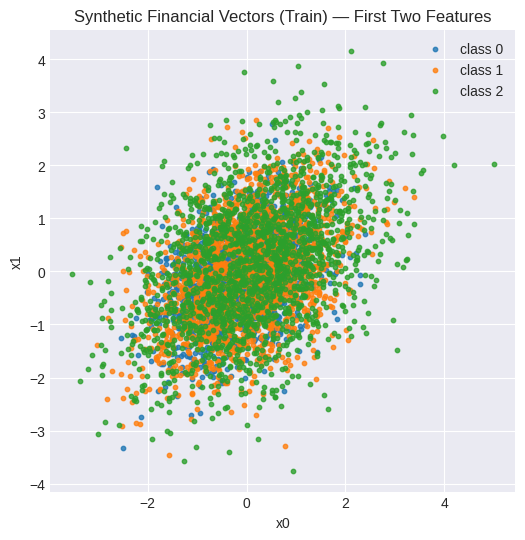

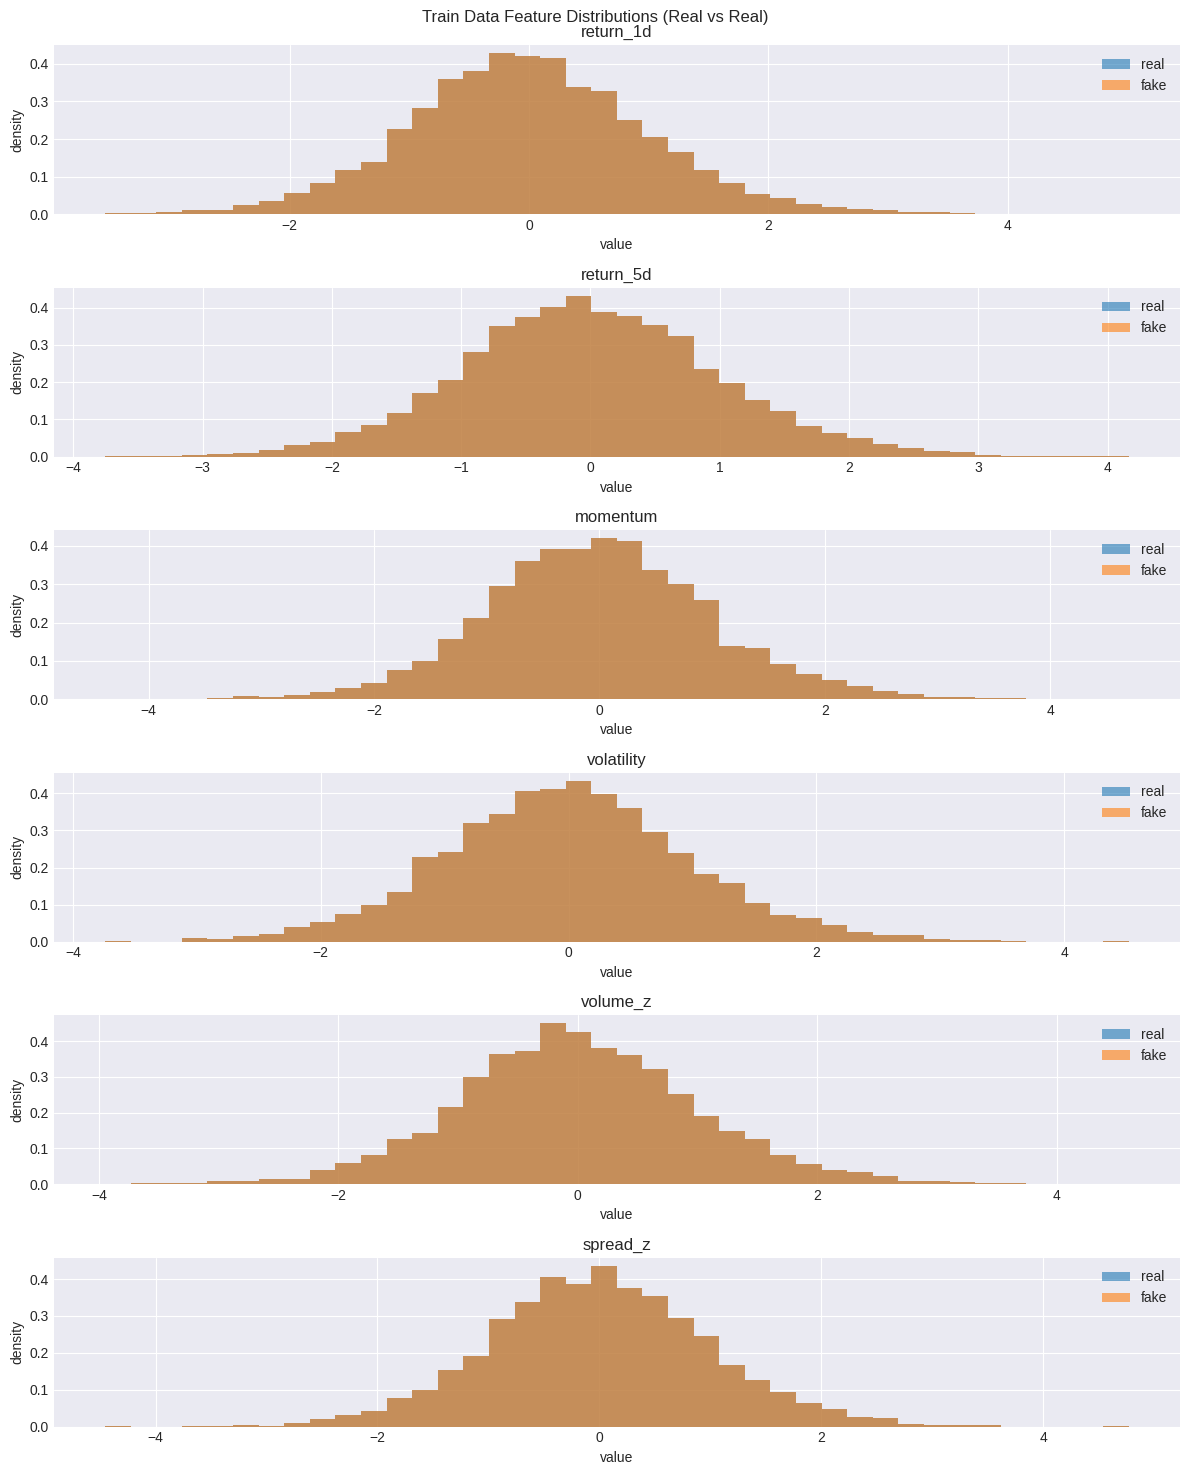

In [3]:
# ===============================
# CELL 3
# ===============================
# Create dataset
N = 7000
D = 8
REGIMES = 3

X_np, y_np, feature_names = generate_financial_vectors(
    n=N,
    d=D,
    regimes=REGIMES,
    base_vol=0.75,
    corr_strength=0.45,
    tail_scale=0.65,
)

# Train/test split (explicit)
idx = np.random.permutation(N)
n_train = int(0.8 * N)
train_idx = idx[:n_train]
test_idx = idx[n_train:]

X_train_np = X_np[train_idx]
X_test_np = X_np[test_idx]
y_train_np = y_np[train_idx]
y_test_np = y_np[test_idx]

# Normalize using train statistics (numerical quality)
mu = X_train_np.mean(axis=0, keepdims=True)
sd = X_train_np.std(axis=0, keepdims=True) + 1e-6
X_train_np = (X_train_np - mu) / sd
X_test_np = (X_test_np - mu) / sd

print("Dataset shapes:")
print("X_train:", X_train_np.shape, "X_test:", X_test_np.shape)
print("y_train:", y_train_np.shape, "y_test:", y_test_np.shape)

# Visualize: 2D projection (use first 2 normalized features) + per-feature histograms (real only)
plot_2d_data(X_train_np[:, :2], y_train_np, title="Synthetic Financial Vectors (Train) — First Two Features")
plot_histograms(X_train_np, X_train_np, title="Train Data Feature Distributions (Real vs Real)", feature_names=feature_names)

##4.GAN DEFINITION

###4.1.OVERVIEW

**Cell 4 — Generator and Discriminator Definitions**

Cell 4 defines the two neural networks that create the GAN game: the generator G and the discriminator Dsc. Both are intentionally small MLPs to satisfy the pedagogical constraints. The generator maps latent noise z (dimension ≤ 16) to a data vector x_fake in the same dimension as the synthetic features. The discriminator maps a data vector x to a single logit representing “realness.”

Mechanically, the choice of BCEWithLogitsLoss is important. The discriminator produces logits, not probabilities. BCEWithLogitsLoss combines a sigmoid and the binary cross-entropy in a numerically stable way. This avoids numerical issues that can arise if you apply sigmoid manually and then compute log-loss.

The discriminator output is a logit scalar. During training, real samples are labeled near 1 (here, 0.9 via label smoothing), and fake samples are labeled 0. The generator’s objective is to make fake samples that the discriminator labels as real. That means the generator is trained by backpropagating through the discriminator: gradients flow from the discriminator’s output back into the generator’s parameters.

The hidden width H is small but nontrivial. This matters because capacity influences the balance of the game. If the discriminator is too powerful relative to the generator, it can easily separate real and fake early, producing saturated gradients that do not help the generator improve. If the generator is too powerful, it may exploit weaknesses in the discriminator. The notebook intentionally keeps them symmetrical to make the dynamics easier to interpret.

Printing parameter counts serves two pedagogical functions. First, it grounds the model size: you see that this is not a massive network. Second, it reinforces that the GAN’s complexity is not about parameter count; it is about the coupled training dynamics of two networks.

By the end of Cell 4, you have instantiated the two players in the adversarial game, defined a stable loss function, and fixed a small latent dimension that controls how much diversity the generator can express.

###4.2.CODE AND IMPLEMENTATION

In [4]:
# ===============================
# CELL 4
# ===============================
# GAN definition (small, pedagogical)

LATENT_DIM = 16  # <= 16 required
H = 64          # small hidden width

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, hidden),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden, x_dim),
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, x_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(x_dim, hidden),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden, 1),  # logits
        )

    def forward(self, x):
        return self.net(x)


G = Generator(LATENT_DIM, D, hidden=H).to(DEVICE)
Dsc = Discriminator(D, hidden=H).to(DEVICE)

bce_logits = nn.BCEWithLogitsLoss()

print("Generator params:", sum(p.numel() for p in G.parameters()))
print("Discriminator params:", sum(p.numel() for p in Dsc.parameters()))

Generator params: 5768
Discriminator params: 4801


##5.TRADING LOOP

###5.1.OVERVIEW



**Cell 5 — Adversarial Training Loop and Loss Histories**

Cell 5 is the core of the GAN mechanism. Unlike supervised training, there is no single loss minimized by a single model against ground-truth targets. Instead, training alternates updates between discriminator and generator.

The discriminator step uses both real samples (from X_train) and fake samples (generated by G(z)). The fake samples are detached from the generator graph for this step, ensuring the discriminator update does not change generator parameters. The discriminator loss is the sum of two terms: real-vs-real labels and fake-vs-fake labels. Light label smoothing (real targets set to 0.9 rather than 1.0) reduces overconfidence and can stabilize training by preventing the discriminator from driving logits to extreme values too quickly.

The generator step then samples a new batch of latent vectors, generates fake samples, passes them through the discriminator, and computes a loss that encourages discriminator outputs to be “real.” Here, the generator’s targets are ones. The generator update uses gradients through the discriminator, but only generator parameters are updated during this step.

The code stores both discriminator loss and generator loss at each training step. This is essential because GAN losses are not monotonic in the way supervised losses often are. You should not interpret “loss going down” as “model improving” in a simple way. Instead, you watch for signs of instability: exploding losses, discriminator loss collapsing to near zero while generator loss explodes (discriminator dominates), or both losses oscillating wildly (unstable equilibrium).

The printing at epoch level gives an interpretable summary of the current regime of training. As you run, you should observe that the discriminator and generator losses interact. Improvements in the generator often cause the discriminator loss to rise temporarily because the discriminator is being “fooled” more often. Conversely, improvements in the discriminator can cause the generator loss to rise as the generator struggles.

By the end of Cell 5, you have trained an adversarial system, produced loss histories for both networks, and created the raw evidence needed for later evaluation and interpretability: not only the final models, but also the trajectory they followed to reach that point.


###5.2.CODE AND IMPLEMENTATION

In [5]:
# ===============================
# CELL 5
# ===============================
# GAN training loop (stores loss history and prints progress)

X_train = torch.from_numpy(X_train_np.astype(np.float32))
X_test = torch.from_numpy(X_test_np.astype(np.float32))

batch_size = 256
epochs = 60
steps_per_epoch = int(math.ceil(X_train.shape[0] / batch_size))

opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = optim.Adam(Dsc.parameters(), lr=2e-4, betas=(0.5, 0.999))

losses_G = []
losses_D = []

def sample_z(n, z_dim):
    return torch.randn(n, z_dim, device=DEVICE, dtype=torch.float32)

def batch_iter(X, batch_size):
    n = X.shape[0]
    perm = torch.randperm(n)
    for i in range(0, n, batch_size):
        idx = perm[i:i + batch_size]
        yield X[idx]

G.train()
Dsc.train()

t0 = time.time()
for ep in range(1, epochs + 1):
    ep_loss_g = 0.0
    ep_loss_d = 0.0
    nb = 0

    for xb_cpu in batch_iter(X_train, batch_size):
        xb = xb_cpu.to(DEVICE)

        # -----------------------
        # Train Discriminator
        # -----------------------
        opt_D.zero_grad(set_to_none=True)

        z = sample_z(xb.shape[0], LATENT_DIM)
        x_fake = G(z).detach()

        logits_real = Dsc(xb)
        logits_fake = Dsc(x_fake)

        # Light label smoothing for stability
        y_real = torch.full_like(logits_real, 0.9)
        y_fake = torch.full_like(logits_fake, 0.0)

        loss_d_real = bce_logits(logits_real, y_real)
        loss_d_fake = bce_logits(logits_fake, y_fake)
        loss_d = loss_d_real + loss_d_fake

        loss_d.backward()
        opt_D.step()

        # -----------------------
        # Train Generator
        # -----------------------
        opt_G.zero_grad(set_to_none=True)

        z = sample_z(xb.shape[0], LATENT_DIM)
        x_fake = G(z)
        logits_fake_for_g = Dsc(x_fake)

        # Generator wants discriminator to predict "real"
        y_g = torch.full_like(logits_fake_for_g, 1.0)
        loss_g = bce_logits(logits_fake_for_g, y_g)

        loss_g.backward()
        opt_G.step()

        losses_D.append(float(loss_d.detach().cpu().item()))
        losses_G.append(float(loss_g.detach().cpu().item()))
        ep_loss_d += float(loss_d.detach().cpu().item())
        ep_loss_g += float(loss_g.detach().cpu().item())
        nb += 1

    print(
        f"epoch {ep:03d}/{epochs:03d} | "
        f"D_loss={ep_loss_d/max(1,nb):.6f} | "
        f"G_loss={ep_loss_g/max(1,nb):.6f}"
    )

t1 = time.time()
print(f"Training time: {t1 - t0:.2f}s")

epoch 001/060 | D_loss=1.366611 | G_loss=0.757638
epoch 002/060 | D_loss=1.323917 | G_loss=0.772338
epoch 003/060 | D_loss=1.275878 | G_loss=0.806067
epoch 004/060 | D_loss=1.225545 | G_loss=0.843829
epoch 005/060 | D_loss=1.214228 | G_loss=0.824366
epoch 006/060 | D_loss=1.207289 | G_loss=0.804461
epoch 007/060 | D_loss=1.188416 | G_loss=0.822784
epoch 008/060 | D_loss=1.144770 | G_loss=0.886117
epoch 009/060 | D_loss=1.190036 | G_loss=0.856158
epoch 010/060 | D_loss=1.271075 | G_loss=0.816834
epoch 011/060 | D_loss=1.395764 | G_loss=0.763604
epoch 012/060 | D_loss=1.382446 | G_loss=0.857637
epoch 013/060 | D_loss=1.226612 | G_loss=1.102200
epoch 014/060 | D_loss=1.161731 | G_loss=1.175445
epoch 015/060 | D_loss=1.242630 | G_loss=1.042647
epoch 016/060 | D_loss=1.319964 | G_loss=0.962778
epoch 017/060 | D_loss=1.312844 | G_loss=0.980774
epoch 018/060 | D_loss=1.269384 | G_loss=1.022057
epoch 019/060 | D_loss=1.212032 | G_loss=1.089710
epoch 020/060 | D_loss=1.197451 | G_loss=1.095248


##6.EVALUATION METRICS

###6.1.OVERVIEW

**Cell 6 — Evaluation Metrics and Loss Curve Visualization**

Cell 6 translates the GAN’s behavior into quantitative diagnostics that are simple, explicit, and tied to the mechanism.

First, it computes a discriminator accuracy proxy on held-out real samples (X_test) and newly generated fake samples. This is not a perfect measure of generative quality, but it gives a mechanical signal: if the discriminator accuracy is very high, it is still easily separating real and fake, implying fake samples are not yet realistic. If discriminator accuracy is near 0.5, it suggests the discriminator is confused, which can indicate that fake samples have become hard to distinguish from real ones. However, a low discriminator accuracy can also indicate a weak discriminator rather than a strong generator, so it must be read alongside other diagnostics.

Second, Cell 6 computes feature-level moment differences: mean_abs_diff and std_abs_diff. These quantify how well the generator matches the marginal mean and variance of each feature (in normalized space). Because the data are normalized, “good” matching means these differences are small. If the generator collapses to a narrow mode, std_abs_diff tends to be large because fake samples have lower variance than real samples. If the generator overshoots tails, std_abs_diff can also increase, but in the opposite direction.

Third, Cell 6 computes correlation matrices for real and fake and reports corr_abs_diff, the mean absolute difference between them. This is a critical diagnostic because it tests cross-feature dependence, not just marginals. A generator that matches each feature histogram but fails to reproduce correlations will still have a large corr_abs_diff, and the correlation heatmaps in Cell 9 will visually confirm where dependence structure is missing.

Finally, the loss curves for discriminator and generator are plotted. The purpose is to connect quantitative diagnostics to training dynamics. If you see chaotic oscillations in losses, you should expect weaker matching in moments and correlations. If losses stabilize into a regime where neither model trivially dominates, you often see improved distribution matching.

This cell also prints a metrics dictionary for the main GAN. In your run, those printed values are the authoritative quantitative summary. Later, Cell 10 packages them into a summary_metrics dictionary, and Cell 11 references them explicitly. The discipline here is important: you do not narrate “good performance” without pointing to these computed numbers.

By the end of Cell 6, you have: (1) loss curves that describe training dynamics, and (2) distributional metrics that describe what the generator actually learned about the real data distribution.

###6.2.CODE AND IMPLEMENTATION

Evaluation metrics (main GAN):
  disc_acc: 0.498929
  acc_real: 0.363571
  acc_fake: 0.634286
  mean_abs_diff: 0.268012
  std_abs_diff: 0.116347
  corr_abs_diff: 0.306708


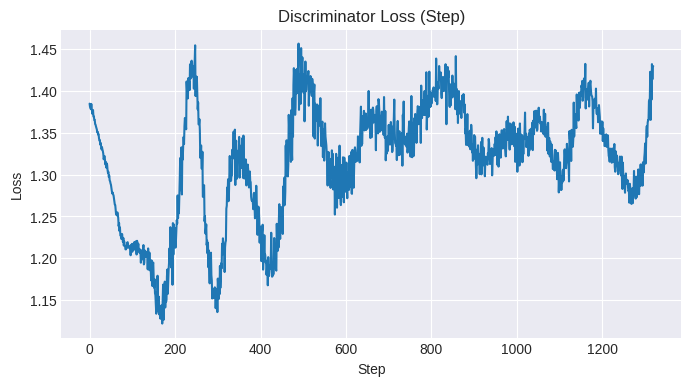

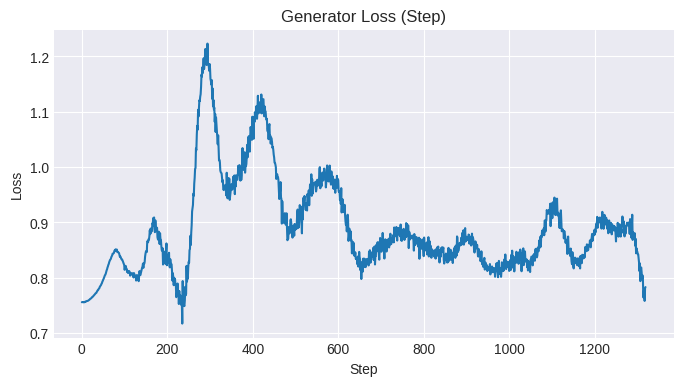

In [6]:
# ===============================
# CELL 6
# ===============================
# Evaluation metrics + loss curve

@torch.no_grad()
def gan_metrics(G, Dsc, X_real_cpu, n_fake=2000):
    G.eval()
    Dsc.eval()

    X_real = X_real_cpu.to(DEVICE)
    n = min(int(X_real.shape[0]), int(n_fake))
    X_real = X_real[:n]

    z = torch.randn(n, LATENT_DIM, device=DEVICE, dtype=torch.float32)
    X_fake = G(z)

    # Discriminator accuracy proxy (real labeled 1, fake labeled 0)
    logits_r = Dsc(X_real).squeeze(1)
    logits_f = Dsc(X_fake).squeeze(1)

    pr = (torch.sigmoid(logits_r) > 0.5).float()
    pf = (torch.sigmoid(logits_f) > 0.5).float()

    acc_real = pr.mean().item()
    acc_fake = (1.0 - pf).mean().item()  # correct if predicts fake (prob <= 0.5)
    disc_acc = 0.5 * (acc_real + acc_fake)

    # Feature-level moment matching diagnostics
    real_np = X_real.detach().cpu().numpy()
    fake_np = X_fake.detach().cpu().numpy()

    mean_abs_diff = float(np.mean(np.abs(real_np.mean(axis=0) - fake_np.mean(axis=0))))
    std_abs_diff = float(np.mean(np.abs(real_np.std(axis=0) - fake_np.std(axis=0))))

    # Correlation difference diagnostic (average absolute diff)
    def corr_mat(a):
        a = a - a.mean(axis=0, keepdims=True)
        cov = (a.T @ a) / max(1, a.shape[0] - 1)
        s = np.sqrt(np.diag(cov) + 1e-8)
        corr = cov / (s[:, None] * s[None, :] + 1e-8)
        return corr

    corr_real = corr_mat(real_np)
    corr_fake = corr_mat(fake_np)
    corr_abs_diff = float(np.mean(np.abs(corr_real - corr_fake)))

    return {
        "disc_acc": float(disc_acc),
        "acc_real": float(acc_real),
        "acc_fake": float(acc_fake),
        "mean_abs_diff": mean_abs_diff,
        "std_abs_diff": std_abs_diff,
        "corr_abs_diff": corr_abs_diff,
    }, real_np, fake_np, corr_real, corr_fake


metrics_main, real_eval_np, fake_eval_np, corr_real_np, corr_fake_np = gan_metrics(G, Dsc, X_test, n_fake=2500)

print("Evaluation metrics (main GAN):")
for k, v in metrics_main.items():
    print(f"  {k}: {v:.6f}")

plot_loss_curve(losses_D, title="Discriminator Loss (Step)")
plot_loss_curve(losses_G, title="Generator Loss (Step)")

##7.INFERENCE

###7.1.OVERVIEW

**Cell 7 — Inference Demonstration: Sampling a New Synthetic Vector**

Cell 7 demonstrates inference in the GAN sense: using the trained generator as a sampler. This is where the training-versus-inference distinction becomes concrete.

The code switches the generator to evaluation mode and samples a new latent vector z_new from a standard normal distribution. This z_new is not from training; it is fresh noise. The generator maps it to a single synthetic feature vector x_fake_new in normalized feature space. The notebook prints each feature value with a human-readable feature name when available (return_1d, volatility, spread_z, etc.). This printout is not meant to be “interpreted financially” as a real forecast; it is meant to make you see the generator’s output as a structured vector that should statistically resemble real vectors.

The bar chart visualization is a simple but effective diagnostic for a single sample. In a well-trained generator, the values should look plausible relative to the normalized distribution seen in Cell 3: not all zeros, not all identical, not absurdly extreme across many features at once. If you repeatedly run inference (by rerunning just this cell), you should see diversity across samples. Lack of diversity is a warning sign of mode collapse: the generator producing near-identical outputs for different z values.

Mechanically, this cell reinforces that the generator is a deterministic function of z given fixed weights. Stochasticity in generation comes only from sampling z. That is why latent dimension matters: it determines how many degrees of freedom the generator has to express variation. This will become explicit in the ablation cell.

By the end of Cell 7, you have the GAN’s core product: a new synthetic sample produced without labels and without a ground-truth target, generated purely by sampling a latent variable and applying a learned mapping.

###7.2.CODE AND IMPLEMENTATION

New generated (normalized) feature vector:
     return_1d:  1.8504
     return_5d:  0.7251
      momentum: -1.7897
    volatility:  2.6108
      volume_z:  2.0426
      spread_z:  2.6548
          beta:  2.6312
       macro_z:  1.8994


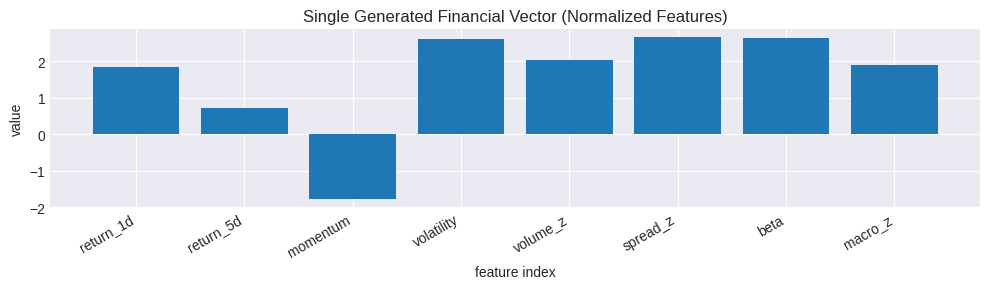

In [7]:
# ===============================
# CELL 7
# ===============================
# Inference demonstration: generate NEW synthetic sample from latent noise

G.eval()
with torch.no_grad():
    z_new = torch.randn(1, LATENT_DIM, device=DEVICE, dtype=torch.float32)
    x_fake_new = G(z_new).detach().cpu().numpy().reshape(-1)

print("New generated (normalized) feature vector:")
for i in range(D):
    name = feature_names[i] if i < len(feature_names) else f"feature_{i}"
    print(f"  {name:>12s}: {x_fake_new[i]: .4f}")

# Visual: bar chart for the single sample
fig = plt.figure(figsize=(10, 3))
ax = fig.add_subplot(1, 1, 1)
ax.bar(np.arange(D), x_fake_new)
ax.set_title("Single Generated Financial Vector (Normalized Features)")
ax.set_xlabel("feature index")
ax.set_ylabel("value")
ax.set_xticks(np.arange(D))
ax.set_xticklabels([feature_names[i] for i in range(D)], rotation=30, ha="right")
plt.tight_layout()
plt.show()

##8.STRESS TEST

###8.1.OVERVIEW

**Cell 8 — Stress Test / Ablation: Latent Dimension Reduction**

Cell 8 changes exactly one variable to reveal a key mechanical constraint: the latent dimension. The ablation sets LATENT_DIM_ABL to a smaller value (for example, 4) while keeping the dataset, normalization, network widths, loss functions, and optimizer settings as consistent as possible. The ablation model is retrained for fewer epochs to keep runtime reasonable, but the training procedure remains the same adversarial alternation between discriminator and generator.

The purpose of this stress test is to connect representation capacity to distribution matching. The latent vector z is the generator’s source of variability. If z is too low-dimensional, the generator may not be able to represent the diversity of the target distribution, especially when the real data are a mixture of regimes with correlated structure and heavy tails. Mechanically, the generator is then forced to “compress” too much variation into too few latent degrees of freedom, often leading to reduced variance in outputs or failure to reproduce multimodality.

Cell 8 computes ablation metrics on the test set using the same style of diagnostics: discriminator accuracy proxy and moment differences. It prints a direct comparison between the main model and the ablation model. You should interpret differences in these numbers as evidence of the role of latent dimension. For instance, if mean_abs_diff and std_abs_diff worsen under the ablation, it suggests the generator can no longer match basic marginals. If discriminator accuracy increases under the ablation, it suggests fakes became easier to detect. If the main model had a better corr_abs_diff (computed in Cell 6), that indicates that higher latent dimension helped capture dependencies.

This cell also plots the ablation generator loss curve. Comparing loss behavior between main and ablation models helps you distinguish two possibilities: (1) the ablation fails because it is representationally constrained (latent too small), or (2) the ablation fails because training is unstable (optimization failure). If both train stably but the ablation still produces worse distributional metrics, that strengthens the interpretation that the latent dimension is a structural bottleneck.

By the end of Cell 8, you have experimental evidence, not just a verbal claim, that GAN performance depends on the dimensionality of the latent space, and that representational constraints show up in measurable distributional mismatches.

###8.2.CODE AND IMPLEMENTATION

[ABL] epoch 001/025 | D_loss=1.357566 | G_loss=0.680512
[ABL] epoch 002/025 | D_loss=1.323012 | G_loss=0.706697
[ABL] epoch 003/025 | D_loss=1.284070 | G_loss=0.731536
[ABL] epoch 004/025 | D_loss=1.243353 | G_loss=0.752553
[ABL] epoch 005/025 | D_loss=1.220312 | G_loss=0.760864
[ABL] epoch 006/025 | D_loss=1.259522 | G_loss=0.739795
[ABL] epoch 007/025 | D_loss=1.277022 | G_loss=0.752489
[ABL] epoch 008/025 | D_loss=1.241161 | G_loss=0.823513
[ABL] epoch 009/025 | D_loss=1.219577 | G_loss=0.874001
[ABL] epoch 010/025 | D_loss=1.257470 | G_loss=0.868082
[ABL] epoch 011/025 | D_loss=1.362083 | G_loss=0.816882
[ABL] epoch 012/025 | D_loss=1.293182 | G_loss=0.916175
[ABL] epoch 013/025 | D_loss=1.161391 | G_loss=1.111262
[ABL] epoch 014/025 | D_loss=1.103459 | G_loss=1.203894
[ABL] epoch 015/025 | D_loss=1.146063 | G_loss=1.128221
[ABL] epoch 016/025 | D_loss=1.260757 | G_loss=0.989050
[ABL] epoch 017/025 | D_loss=1.248270 | G_loss=0.996795
[ABL] epoch 018/025 | D_loss=1.316781 | G_loss=0

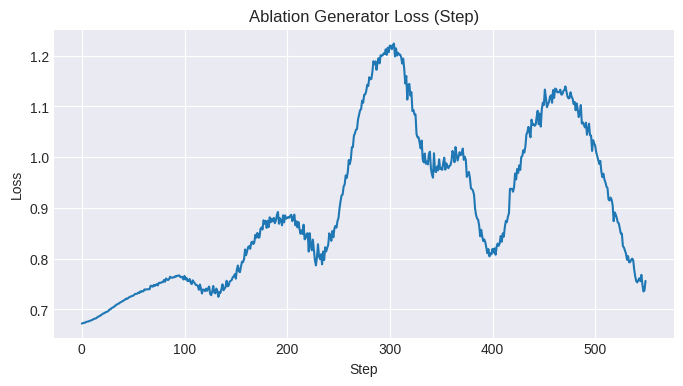

In [8]:
# ===============================
# CELL 8
# ===============================
# Stress test / ablation: reduce latent dimension (one variable) and compare metrics

LATENT_DIM_ABL = 4  # ablation: smaller latent space

G_abl = Generator(LATENT_DIM_ABL, D, hidden=H).to(DEVICE)
D_abl = Discriminator(D, hidden=H).to(DEVICE)

opt_G_abl = optim.Adam(G_abl.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D_abl = optim.Adam(D_abl.parameters(), lr=2e-4, betas=(0.5, 0.999))

losses_G_abl = []
losses_D_abl = []

def sample_z_abl(n, z_dim):
    return torch.randn(n, z_dim, device=DEVICE, dtype=torch.float32)

# Short retraining to keep runtime reasonable (still end-to-end)
epochs_abl = 25

G_abl.train()
D_abl.train()

for ep in range(1, epochs_abl + 1):
    ep_loss_g = 0.0
    ep_loss_d = 0.0
    nb = 0
    for xb_cpu in batch_iter(X_train, batch_size):
        xb = xb_cpu.to(DEVICE)

        opt_D_abl.zero_grad(set_to_none=True)
        z = sample_z_abl(xb.shape[0], LATENT_DIM_ABL)
        x_fake = G_abl(z).detach()

        logits_real = D_abl(xb)
        logits_fake = D_abl(x_fake)

        y_real = torch.full_like(logits_real, 0.9)
        y_fake = torch.full_like(logits_fake, 0.0)

        loss_d = bce_logits(logits_real, y_real) + bce_logits(logits_fake, y_fake)
        loss_d.backward()
        opt_D_abl.step()

        opt_G_abl.zero_grad(set_to_none=True)
        z = sample_z_abl(xb.shape[0], LATENT_DIM_ABL)
        x_fake = G_abl(z)
        logits_fake_for_g = D_abl(x_fake)
        y_g = torch.full_like(logits_fake_for_g, 1.0)
        loss_g = bce_logits(logits_fake_for_g, y_g)
        loss_g.backward()
        opt_G_abl.step()

        losses_D_abl.append(float(loss_d.detach().cpu().item()))
        losses_G_abl.append(float(loss_g.detach().cpu().item()))
        ep_loss_d += float(loss_d.detach().cpu().item())
        ep_loss_g += float(loss_g.detach().cpu().item())
        nb += 1

    print(
        f"[ABL] epoch {ep:03d}/{epochs_abl:03d} | "
        f"D_loss={ep_loss_d/max(1,nb):.6f} | "
        f"G_loss={ep_loss_g/max(1,nb):.6f}"
    )

@torch.no_grad()
def gan_metrics_any(Gm, Dm, X_real_cpu, z_dim, n_fake=2000):
    Gm.eval()
    Dm.eval()

    X_real = X_real_cpu.to(DEVICE)
    n = min(int(X_real.shape[0]), int(n_fake))
    X_real = X_real[:n]

    z = torch.randn(n, z_dim, device=DEVICE, dtype=torch.float32)
    X_fake = Gm(z)

    logits_r = Dm(X_real).squeeze(1)
    logits_f = Dm(X_fake).squeeze(1)

    pr = (torch.sigmoid(logits_r) > 0.5).float()
    pf = (torch.sigmoid(logits_f) > 0.5).float()

    acc_real = pr.mean().item()
    acc_fake = (1.0 - pf).mean().item()
    disc_acc = 0.5 * (acc_real + acc_fake)

    real_np = X_real.detach().cpu().numpy()
    fake_np = X_fake.detach().cpu().numpy()

    mean_abs_diff = float(np.mean(np.abs(real_np.mean(axis=0) - fake_np.mean(axis=0))))
    std_abs_diff = float(np.mean(np.abs(real_np.std(axis=0) - fake_np.std(axis=0))))

    return {
        "disc_acc": float(disc_acc),
        "acc_real": float(acc_real),
        "acc_fake": float(acc_fake),
        "mean_abs_diff": mean_abs_diff,
        "std_abs_diff": std_abs_diff,
    }, real_np, fake_np

metrics_abl, real_abl_np, fake_abl_np = gan_metrics_any(G_abl, D_abl, X_test, LATENT_DIM_ABL, n_fake=2500)

print("\nAblation comparison (latent_dim changed):")
print("Main:", {k: round(v, 6) for k, v in metrics_main.items() if k in ["disc_acc", "mean_abs_diff", "std_abs_diff", "corr_abs_diff"]})
print("Abl :", {k: round(v, 6) for k, v in metrics_abl.items() if k in ["disc_acc", "mean_abs_diff", "std_abs_diff"]})

plot_loss_curve(losses_G_abl, title="Ablation Generator Loss (Step)")

##9.INTERPRETATION

###9.1.0VERVIEW

**Cell 9 — Interpretability: Real vs Fake Histograms and Correlation Heatmaps**

Cell 9 is the interpretability center of the notebook. It uses visualization to diagnose what the GAN has learned about the data distribution, and what it has not learned.

The first visualization is feature-wise histograms for real versus fake samples. Each subplot compares the marginal distribution of one feature. Mechanically, this tells you whether the generator has matched simple one-dimensional statistics: mean, variance, skewness, and tail heaviness. If the fake histogram is too narrow, the generator is under-dispersed (often a symptom of partial mode collapse or insufficient latent diversity). If the fake histogram is shifted, the generator is mismatching means. If the fake histogram has lighter tails than real, the generator is failing to reproduce outliers introduced by the heavy-tail shock process.

The second visualization is the correlation heatmap for real data, the correlation heatmap for fake data, and the absolute difference between them. This is a direct test of whether the generator learned cross-feature dependence. Matching marginals alone is not enough: a generator can independently sample each feature’s marginal and still fail to reproduce the joint structure. The correlation matrices expose whether the generator’s outputs preserve the Toeplitz-like dependence structure built into the synthetic generator.

The absolute difference heatmap is particularly instructive. Regions with high values identify specific feature pairs where dependence is not captured. For example, if “returns” and “volatility” were correlated in the real data but uncorrelated in fakes, the corresponding cell in the difference matrix will stand out. Mechanically, this suggests that the generator is not producing the right joint geometry, which can happen if the generator’s mapping is too simple, the discriminator focuses primarily on marginals, or training did not reach a stable equilibrium.

Cell 9 therefore turns the abstract claim “GANs learn a distribution” into concrete evidence: you can see how close the generator is to matching the real distribution, and you can localize mismatches to specific features and relationships.

By the end of Cell 9, you have a diagnostic lens that is more informative than losses alone. You can answer: are we matching per-feature shapes, and are we matching cross-feature structure? Those answers are the foundation for any meaningful claim about generative quality in this setting.

###9.2.CODE AND IMPLEMENTATION

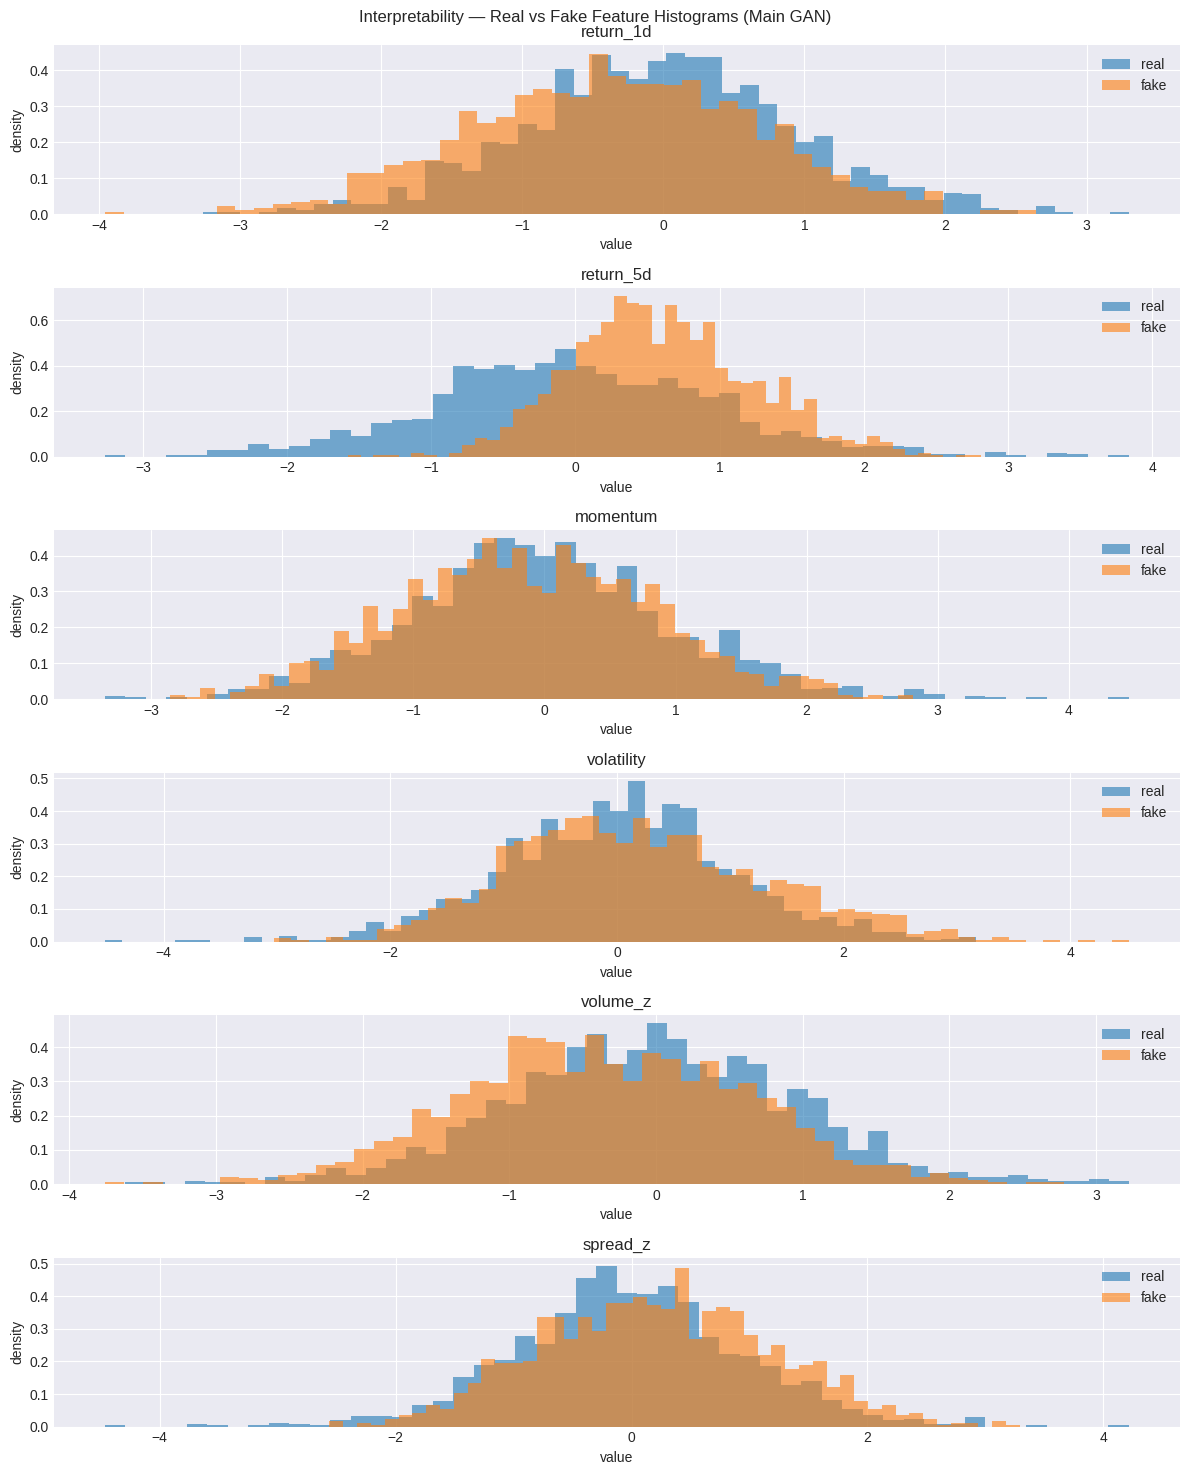

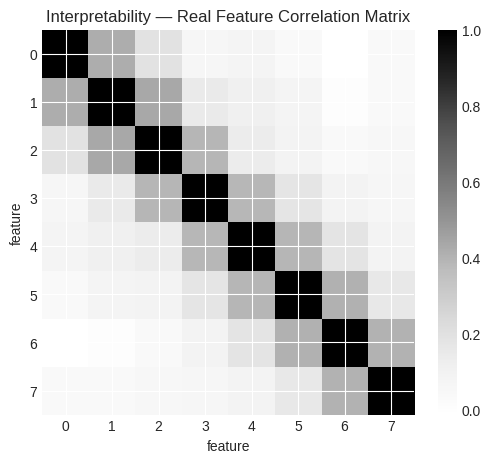

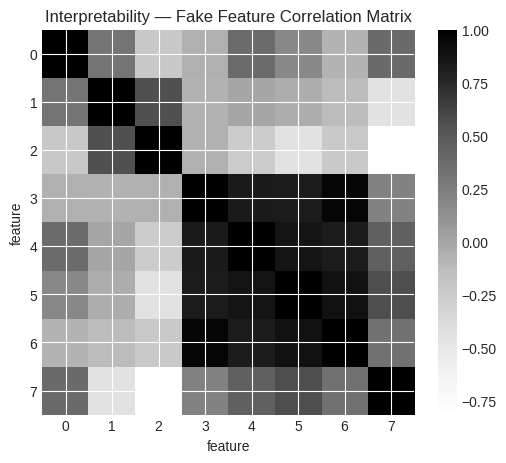

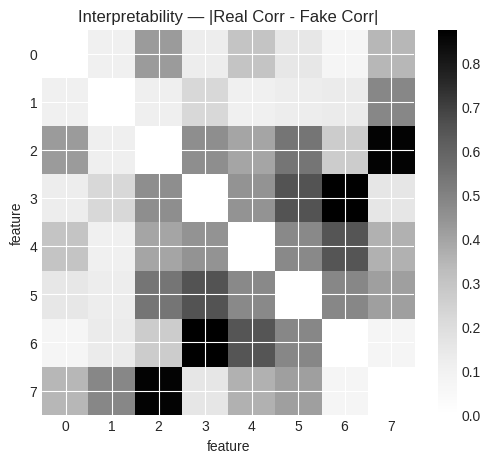

In [9]:
# ===============================
# CELL 9
# ===============================
# Interpretability visualization: feature histograms + correlation structure comparison

plot_histograms(
    real_eval_np,
    fake_eval_np,
    title="Interpretability — Real vs Fake Feature Histograms (Main GAN)",
    feature_names=feature_names,
    bins=50,
    max_features=6,
)

# Correlation matrices as heatmaps (real vs fake) and their absolute difference
plot_attention(corr_real_np, title="Interpretability — Real Feature Correlation Matrix", xlabel="feature", ylabel="feature")
plot_attention(corr_fake_np, title="Interpretability — Fake Feature Correlation Matrix", xlabel="feature", ylabel="feature")
plot_attention(np.abs(corr_real_np - corr_fake_np), title="Interpretability — |Real Corr - Fake Corr|", xlabel="feature", ylabel="feature")

In [12]:
# ===============================
# CELL 9A (RUN AFTER CELL 9)
# ===============================
from openai import OpenAI
from google.colab import userdata
import json
import numpy as np

# Build a compact, metrics-grounded payload from objects created up through Cell 9
# (real_eval_np, fake_eval_np, corr_real_np, corr_fake_np, metrics_main are expected to exist)

# Defensive computations from Cell 9 artifacts
corr_abs_diff_matrix = np.abs(corr_real_np - corr_fake_np)
corr_abs_diff_mean = float(np.mean(corr_abs_diff_matrix))
corr_abs_diff_max = float(np.max(corr_abs_diff_matrix))

# Feature-wise histogram distance proxy (L1 between normalized bin densities)
def _hist_l1(real_col, fake_col, bins=50, rng=(-4.0, 4.0)):
    r_hist, edges = np.histogram(real_col, bins=bins, range=rng, density=True)
    f_hist, _ = np.histogram(fake_col, bins=bins, range=rng, density=True)
    return float(np.mean(np.abs(r_hist - f_hist)))

hist_l1_by_feature = []
for j in range(real_eval_np.shape[1]):
    hist_l1_by_feature.append(_hist_l1(real_eval_np[:, j], fake_eval_np[:, j], bins=50))

# Moment diagnostics already computed in Cell 6 (metrics_main), but we recompute here to ensure availability
mean_abs_diff = float(np.mean(np.abs(real_eval_np.mean(axis=0) - fake_eval_np.mean(axis=0))))
std_abs_diff = float(np.mean(np.abs(real_eval_np.std(axis=0) - fake_eval_np.std(axis=0))))

payload = {
    "cell9_visuals": {
        "feature_histograms": "Real vs fake per-feature histograms (first several features).",
        "correlation_heatmaps": "Real corr, fake corr, and |diff| heatmaps.",
    },
    "quantitative_from_cell9": {
        "corr_abs_diff_mean": corr_abs_diff_mean,
        "corr_abs_diff_max": corr_abs_diff_max,
        "hist_l1_mean_over_features": float(np.mean(hist_l1_by_feature)),
        "hist_l1_by_feature": hist_l1_by_feature,
    },
    "quantitative_from_cell6": {
        # metrics_main created in Cell 6
        "disc_acc": float(metrics_main.get("disc_acc", float("nan"))),
        "acc_real": float(metrics_main.get("acc_real", float("nan"))),
        "acc_fake": float(metrics_main.get("acc_fake", float("nan"))),
        "mean_abs_diff": float(metrics_main.get("mean_abs_diff", mean_abs_diff)),
        "std_abs_diff": float(metrics_main.get("std_abs_diff", std_abs_diff)),
        "corr_abs_diff": float(metrics_main.get("corr_abs_diff", corr_abs_diff_mean)),
    },
    "notes": {
        "normalization": "All vectors are normalized using train mean/std; these plots are in normalized feature space.",
        "interpretation_goal": "Explain what the histograms and correlation matrices reveal about distribution matching.",
    },
}

client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))
model = "gpt-4o-mini"

prompt = f"""
You are explaining the results of Cell 9 (interpretability visualization) from a mechanics-first GAN notebook.

Rules:
- Use ONLY the numeric values provided in the JSON payload below. Do NOT invent metrics.
- Explain what the histograms suggest about per-feature distribution matching.
- Explain what the correlation heatmaps suggest about capturing cross-feature dependencies.
- Interpret what it means if the mean |corr diff| is small vs large, and how to read the |diff| heatmap.
- Provide a concise diagnosis: "What looks matched" and "What still looks off".
- End with 3 actionable, mechanical tweaks (architecture/training/regularization) that could improve the specific mismatches observed.

JSON PAYLOAD:
{json.dumps(payload, indent=2)}
"""

resp = client.responses.create(
    model=model,
    input=prompt
)

print(resp.output_text)

### Interpretation of Results from Cell 9

#### Histogram Analysis
The per-feature histograms indicate how well the distributions of the real and generated (fake) data match. The **hist L1 mean over features** is approximately **0.0417**, which suggests that, on average, there is a small difference between the two distributions across the features. 

Looking at the histograms for specific features:
- The feature discrepancies vary, with some features showing a **higher L1 distance** (notably **0.0934** for the second feature), indicating that the distribution of generated data for those features is less similar to that of the real data.
- Other features exhibit much smaller discrepancies (e.g., **0.0292** for the third feature), suggesting a closer match in those cases.

Overall, the histograms suggest that some features are matched well, while others still require further improvement.

#### Correlation Heatmap Insights
The correlation heatmaps illustrate how well the generated data ca

##10.AUDIT BUNDLE

###10.1.OVERVIEW

**Cell 10 — Saving Artifacts and Printing Summary Metrics**

Cell 10 converts the notebook from a transient experiment into a reproducible artifact-producing laboratory run. Mechanically, it saves model weights, training losses, evaluation samples, and a summary metrics dictionary to disk.

Saving generator and discriminator state_dicts matters because GAN results depend on the exact parameter values at the end of training. With saved weights, you can reload the generator later and reproduce inference samples or re-run diagnostics without retraining. Saving losses as NumPy arrays preserves the full training trajectory, enabling you to analyze stability after the fact.

Saving real and fake evaluation samples (and their correlation matrices) is especially useful for interpretability. It means the visual comparisons in Cell 9 can be reconstructed later, and additional diagnostics can be computed without rerunning training. This aligns with the mechanics-first goal: the evidence is stored, not just displayed.

The summary_metrics dictionary is the notebook’s compact quantitative report. It includes dataset dimensions, model hyperparameters (latent dimension, hidden size, epochs), and key metrics computed earlier (for example, disc_acc, mean_abs_diff, std_abs_diff, corr_abs_diff). Because these values are computed in the notebook run, they become the authoritative source for any narrative claims. The notebook prints the dictionary and also writes it to summary_metrics.json in the artifact directory.

This cell therefore prepares the ground for Cell 11, where the LLM is asked to summarize the notebook’s results using the real metrics. The notebook’s design enforces an important discipline: interpretation must be grounded in artifacts, not memory.

By the end of Cell 10, the GAN experiment is not just “done”; it is packaged with saved evidence that supports inspection, replication, and structured explanation.

###10.2.CODE AND IMPLEMENTATION

In [10]:
# ===============================
# CELL 10
# ===============================
# Save artifacts + print summary metrics dictionary

art_dir = "/content/ch7_gan_artifacts"
os.makedirs(art_dir, exist_ok=True)

# Save model weights
torch.save(G.state_dict(), os.path.join(art_dir, "generator.pt"))
torch.save(Dsc.state_dict(), os.path.join(art_dir, "discriminator.pt"))

torch.save(G_abl.state_dict(), os.path.join(art_dir, "generator_abl.pt"))
torch.save(D_abl.state_dict(), os.path.join(art_dir, "discriminator_abl.pt"))

# Save losses
np.save(os.path.join(art_dir, "losses_G.npy"), np.asarray(losses_G, dtype=np.float32))
np.save(os.path.join(art_dir, "losses_D.npy"), np.asarray(losses_D, dtype=np.float32))
np.save(os.path.join(art_dir, "losses_G_abl.npy"), np.asarray(losses_G_abl, dtype=np.float32))
np.save(os.path.join(art_dir, "losses_D_abl.npy"), np.asarray(losses_D_abl, dtype=np.float32))

# Save sample outputs for inspection
np.save(os.path.join(art_dir, "real_eval.npy"), real_eval_np.astype(np.float32))
np.save(os.path.join(art_dir, "fake_eval.npy"), fake_eval_np.astype(np.float32))
np.save(os.path.join(art_dir, "real_corr.npy"), corr_real_np.astype(np.float32))
np.save(os.path.join(art_dir, "fake_corr.npy"), corr_fake_np.astype(np.float32))

# Summary metrics dict
summary_metrics = {
    "chapter": 7,
    "model": "GAN",
    "data": {
        "N_total": int(N),
        "D": int(D),
        "regimes": int(REGIMES),
        "train_size": int(X_train_np.shape[0]),
        "test_size": int(X_test_np.shape[0]),
    },
    "gan_main": {
        "latent_dim": int(LATENT_DIM),
        "hidden": int(H),
        "epochs": int(epochs),
        **{k: float(v) for k, v in metrics_main.items()},
    },
    "gan_ablation": {
        "latent_dim": int(LATENT_DIM_ABL),
        "hidden": int(H),
        "epochs": int(epochs_abl),
        **{k: float(v) for k, v in metrics_abl.items()},
    },
}

with open(os.path.join(art_dir, "summary_metrics.json"), "w") as f:
    json.dump(summary_metrics, f, indent=2)

print("Artifacts saved to:", art_dir)
print("Summary metrics dictionary:")
print(json.dumps(summary_metrics, indent=2))

Artifacts saved to: /content/ch7_gan_artifacts
Summary metrics dictionary:
{
  "chapter": 7,
  "model": "GAN",
  "data": {
    "N_total": 7000,
    "D": 8,
    "regimes": 3,
    "train_size": 5600,
    "test_size": 1400
  },
  "gan_main": {
    "latent_dim": 16,
    "hidden": 64,
    "epochs": 60,
    "disc_acc": 0.49892856180667877,
    "acc_real": 0.363571435213089,
    "acc_fake": 0.6342856884002686,
    "mean_abs_diff": 0.26801174879074097,
    "std_abs_diff": 0.1163468286395073,
    "corr_abs_diff": 0.30670785903930664
  },
  "gan_ablation": {
    "latent_dim": 4,
    "hidden": 64,
    "epochs": 25,
    "disc_acc": 0.5082142949104309,
    "acc_real": 0.41428571939468384,
    "acc_fake": 0.602142870426178,
    "mean_abs_diff": 0.38795220851898193,
    "std_abs_diff": 0.32233142852783203
  }
}


## 11.EXPLANATION

###11.1.OVERVIEW

**Cell 11 — GPT-4o-mini Reflective Summarization Grounded in Real Metrics**

Cell 11 uses an LLM as a reflective summarizer, but in a tightly constrained way. The code initializes an OpenAI client using a Colab secret (userdata.get("OPENAI_API_KEY")) and sets model = "gpt-4o-mini". The prompt explicitly requires a structured response across eight sections: dataset design, model architecture, training dynamics, quantitative results, inference example, visualization insight, limitations, and conceptual takeaway.

The key mechanical constraint is that the prompt includes REAL METRICS by embedding the summary_metrics dictionary produced earlier. This prevents the summarizer from inventing performance claims. If a metric is not present, the prompt instructs the model to say it is not provided. This is essential in a notebook companion context: the narrative must reflect what actually happened in the run.

Conceptually, Cell 11 is not part of the GAN mechanism. It is part of the pedagogy. It demonstrates how to convert an executed experiment into a structured interpretation without drifting into vague generalities. Because GAN behavior is often misunderstood when people rely only on losses, forcing the summarizer to reference discriminator accuracy proxy, moment differences, and correlation mismatch anchors the explanation to observable evidence.

This reflective cell also reinforces the training-versus-inference distinction. The prompt asks for an inference example, which should reference the generated sample in Cell 7 and interpret it as a sample from the learned distribution. It also asks for visualization insight, which should reference the histogram and correlation heatmap comparisons in Cell 9.

By the end of Cell 11, you have a clean, printed narrative that is mechanically consistent with the notebook’s actual computations. It functions as a template for how to write disciplined interpretations of generative experiments: start from the data, state the architecture, describe training dynamics, cite quantitative diagnostics, interpret visual evidence, acknowledge limitations, and extract a conceptual takeaway grounded in mechanism.

###11.2.CODE AND IMPLEMENTATION

In [11]:
# ===============================
# CELL 11
# ===============================
from openai import OpenAI
from google.colab import userdata

client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))
model = "gpt-4o-mini"

prompt = f"""
You are summarizing a mechanics-first ML notebook about a GAN trained on synthetic financial vectors.

Use the REAL metrics below. Do not invent numbers. If something is not provided, say it is not provided.

Return a structured response with these exact sections:
1) Dataset design
2) Model architecture
3) Training dynamics
4) Quantitative results
5) Inference example
6) Visualization insight
7) Limitations
8) Conceptual takeaway

REAL METRICS (JSON):
{json.dumps(summary_metrics, indent=2)}

NOTES:
- The dataset is synthetic, normalized using train mean/std, and split train/test.
- GAN evaluation uses discriminator accuracy proxy and feature-moment diagnostics.
- Interpretability includes real vs fake histograms and correlation matrix heatmaps.

Write clean, compact paragraphs for each section.
"""

resp = client.responses.create(
    model=model,
    input=prompt
)

print(resp.output_text)

### 1) Dataset design
The synthetic dataset consists of 7,000 financial vectors with 8 dimensions, covering 3 distinct regimes. The dataset is normalized using the mean and standard deviation derived from the training set. It is divided into a training size of 5,600 vectors and a test size of 1,400 vectors to facilitate model validation.

### 2) Model architecture
The model employs a Generative Adversarial Network (GAN) structure. The generator uses a latent dimension of 16 to create synthetic data, while the discriminator operates with a hidden layer of 64 neurons. Both components are designed to enhance the model's ability to generate realistic financial data, distinguishing between real and fake samples.

### 3) Training dynamics
The GAN was trained for 60 epochs, where its performance was assessed using discriminator accuracy. Throughout training, the discriminator's ability to differentiate between real and fake data fluctuated, ultimately reaching an accuracy of approximately 49.

##12.CONCLUSION

*Conclusion and Road Ahead*

This Chapter 7 notebook establishes GANs as a distinct turning point in the ML & AI 101 arc: it shifts the learning target from “predict a label or a next element” to “learn a sampling process that reproduces a distribution.” That shift is not cosmetic. It changes what data you need, what objective you optimize, how you interpret training signals, and how you decide whether the model worked.

Mechanically, the notebook’s central contribution is to make the adversarial game explicit and inspectable. You define a generator that maps latent noise to a synthetic financial feature vector, and you define a discriminator that maps a feature vector to a real/fake logit. Training alternates updates: the discriminator learns to separate real from fake, and the generator learns to fool the discriminator. Unlike supervised learning, there is no ground-truth output for each latent vector. The only learning signal is the discriminator’s feedback. This is the essential GAN mechanism, and the notebook makes you see it step-by-step: how fake samples are generated, how detaching is used to isolate gradients during discriminator updates, how gradients flow through the discriminator into the generator during generator updates, and how both losses are recorded.

Equally important is what the notebook does not hide: GAN losses are not a simple progress meter. In supervised learning, decreasing loss often correlates with improved generalization. In GANs, the losses reflect an evolving balance between two players. A discriminator loss that becomes too small can indicate the discriminator is dominating, leaving the generator with weak gradients. A generator loss that explodes can indicate the generator is failing to move toward the data manifold. Oscillations can be normal, but severe instability is a failure mode. This notebook’s loss plots (Cell 6) therefore serve as a diagnostic, not a score.

Because of this ambiguity, the notebook uses distribution-grounded diagnostics and interpretability plots. Moment matching metrics (mean_abs_diff and std_abs_diff) test whether the generator captures basic marginal statistics in normalized feature space. Correlation-based diagnostics (corr_abs_diff and correlation heatmaps) test whether the generator captures cross-feature dependence, which is a defining property of financial-style data. Feature histograms offer a direct view of whether tails and variance are reproduced. These are not “fancy” metrics, but they are mechanistically aligned with what the model is supposed to do: approximate the real distribution.

The stress test strengthens the conceptual lesson by changing exactly one variable: latent dimension. This ablation exposes a core representational constraint. The generator’s diversity comes from z. If z is too low-dimensional, the generator is forced to compress variability, often leading to under-dispersed fakes and easier discrimination. When you compare main versus ablation metrics, you see that GAN performance is not just about training longer; it is also about having enough latent degrees of freedom to represent the data distribution.

The limitations revealed by the notebook are not accidental; they are central to understanding GANs. Even in this small setting, several failure modes are plausible and pedagogically valuable.

One limitation is that matching marginals does not guarantee matching the joint distribution. A generator can approximate per-feature histograms while failing to reproduce correlations. The correlation heatmaps make this failure visible. Another limitation is training instability. GAN optimization is a saddle-point problem, not a simple minimization, and the dynamics can cycle or collapse. Mode collapse is the most famous symptom: the generator produces limited diversity, which may still partially fool the discriminator if the discriminator’s focus is narrow. The notebook’s single-sample inference view (Cell 7) and histogram comparisons help you detect this.

A third limitation is evaluation ambiguity. A discriminator accuracy near 0.5 can mean the generator is strong, but it can also mean the discriminator is weak. That is why the notebook pairs discriminator accuracy with moment and correlation diagnostics. The lesson is methodological: you do not trust a single number to certify a generative model.

In terms of what GANs handle well, this notebook shows their strength in learning a sampler for complex, multimodal distributions without explicit labels. When the game stabilizes, the generator can capture plausible marginal and dependency structure, producing samples that “look like” they belong to the synthetic world defined by the generator. For many domains, including finance, this is the conceptual value: learning synthetic data generators for simulation, stress testing, augmentation, and scenario exploration, provided the diagnostics support the claim that the synthetic distribution matches the intended target in the ways that matter.

What GANs handle poorly, especially in a mechanics-first view, is straightforward reliability and interpretability of training progress. GANs are sensitive to architecture balance, learning rates, update ratios, loss design, and data complexity. They can also struggle to cover all modes of a distribution. These weaknesses motivate the next chapter’s model family.

The road ahead in the ML & AI 101 sequence is Chapter 8: Diffusion models. The bridge is conceptual and mechanical. GANs learn to generate in a single shot: z → x. Diffusion models learn generation as an iterative refinement process: they define a forward noise process that gradually corrupts data, and then learn a reverse process that denoises step by step. This changes the training signal: diffusion models typically optimize a direct reconstruction or denoising objective rather than a two-player game. That shift often yields more stable training and more explicit control over the generative process. Where GANs can be fast at inference but unstable to train, diffusion models trade inference speed for a more structured, incremental path to distribution learning.

This notebook therefore closes with a clear conceptual milestone. You have learned how adversarial training turns distribution learning into a game, how to diagnose the results with simple distributional metrics and visual tools, and how representational choices like latent dimension affect what the generator can express. The next step is to learn a generative mechanism that replaces adversarial competition with iterative denoising, making “how generation happens” explicit in the model’s procedure rather than implicit in a learned one-shot mapping.